In [9]:
from pynq import Overlay, allocate
import numpy as np
import cv2
import PIL.Image

ol = Overlay("sobel.bit")

dma_send = ol.axi_dma_0.sendchannel
dma_recv = ol.axi_dma_0.recvchannel

(720, 1280)


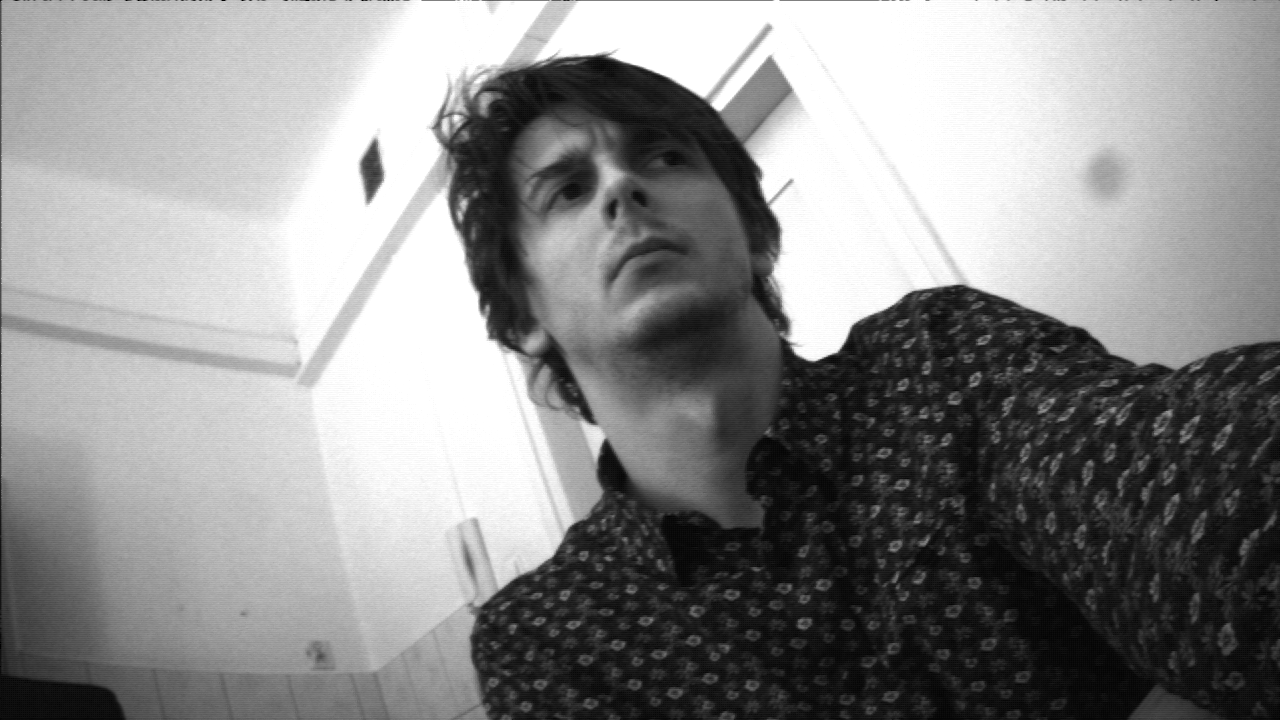

In [10]:
img_shape = (720, 1280)
output_shape = (718, 1278)
input_buffer = allocate(shape=img_shape, dtype=np.uint8)
output_buffer = allocate(shape=output_shape, dtype=np.uint8)

test_img = cv2.imread("testimg.png")
test_img = test_img[:, :, [2, 1, 0]]
test_img = test_img[:, :, 0]
input_buffer[:] = test_img
print(test_img.shape)
PIL.Image.fromarray(input_buffer)

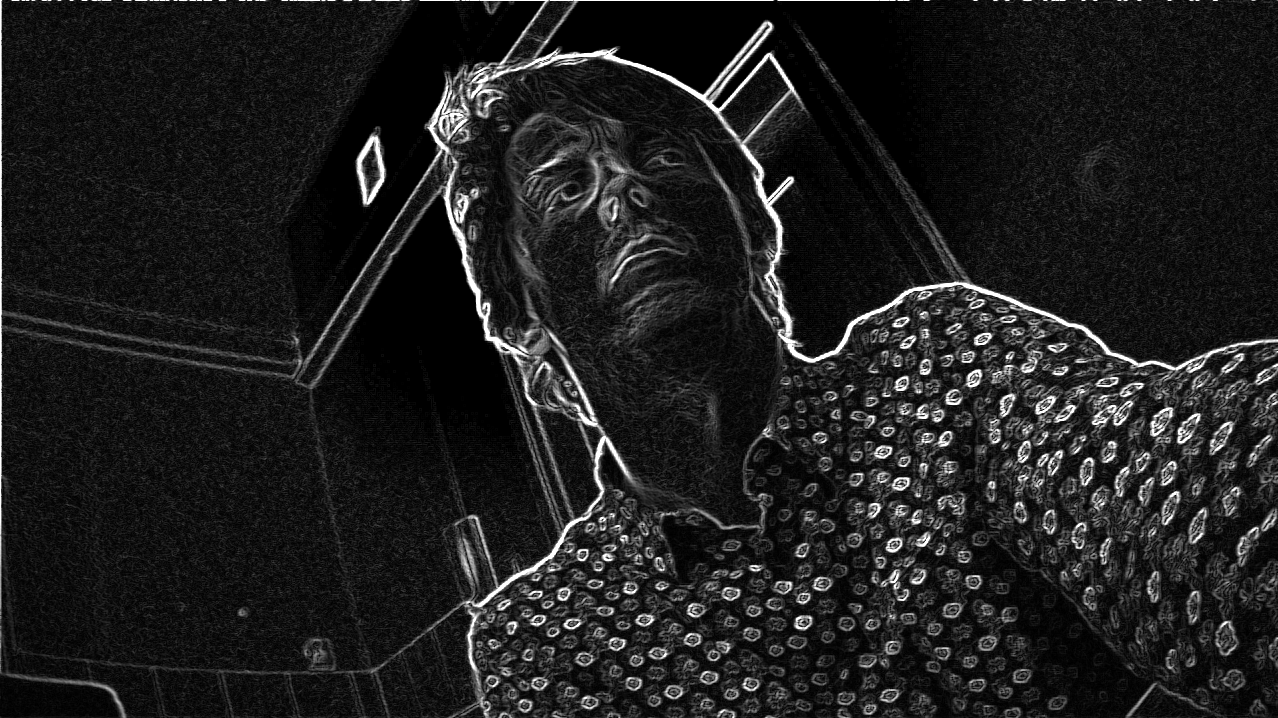

In [11]:
dma_send.transfer(input_buffer)
dma_recv.transfer(output_buffer)
dma_send.wait()
dma_recv.wait()
    
# print((output_buffer == input_buffer).all())
PIL.Image.fromarray(output_buffer)

In [15]:
def hex_to_signed_int(hex_str, bits, u2=True):
    """Converts a hex string to a signed integer based on bit-width."""
    val = int(hex_str, 16)
    if u2 and val & (1 << (bits - 1)):
        val -= (1 << bits)
    return val


def signed_to_u2_hex(val, bits=8):
    """
    Converts a signed integer to a two's complement hex string.
    """
    # 1. Apply bitmask to handle negative numbers and constrain width
    # This maps -1 to 0xFFFF (for 16 bits)
    mask = (1 << bits) - 1
    u2_val = val & mask
    
    return u2_val
    
    # 2. Format as hex string with padding
    # '0' padding, 'bits//4' length, 'x' for lowercase hex
    hex_chars = bits // 4
    return f"{u2_val:0{hex_chars}x}".upper()

In [20]:
np.set_printoptions(formatter=None)
print(test_img[0, 0])
np.set_printoptions(formatter={'int':lambda x:hex(int(x))})
print(test_img[0, 0])

print()
np.set_printoptions(formatter=None)
print(test_img[0, 1])
np.set_printoptions(formatter={'int':lambda x:hex(int(x))})
print(test_img[0, 1])

[ 14 145 150]
[0xe 0x91 0x96]

[ 64 168 172]
[0x40 0xa8 0xac]
